<a href="https://colab.research.google.com/github/vtu24392/mlt-lab/blob/main/MLT_Task06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TASK 06
## To implement the Gaussian mixture model


=== Dataset: Iris | samples: 150 features: 4 classes: 3 ===
Accuracy: 0.8000
Mapping (pred_cluster -> true_label): {np.int64(0): np.int64(0), np.int64(2): np.int64(1), np.int64(1): np.int64(2)}
Confusion matrix (rows=true labels, cols=pred clusters):
 [[15  0  0]
 [ 0  1 14]
 [ 0  7  8]]
Classification report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.64      0.93      0.76        15
           2       0.88      0.47      0.61        15

    accuracy                           0.80        45
   macro avg       0.84      0.80      0.79        45
weighted avg       0.84      0.80      0.79        45


=== Dataset: Wine | samples: 178 features: 13 classes: 3 ===
Accuracy: 0.9630
Mapping (pred_cluster -> true_label): {np.int64(1): np.int64(0), np.int64(2): np.int64(1), np.int64(0): np.int64(2)}
Confusion matrix (rows=true labels, cols=pred clusters):
 [[ 0 18  0]
 [ 2  0 19]
 [15  0  0]]
Classification

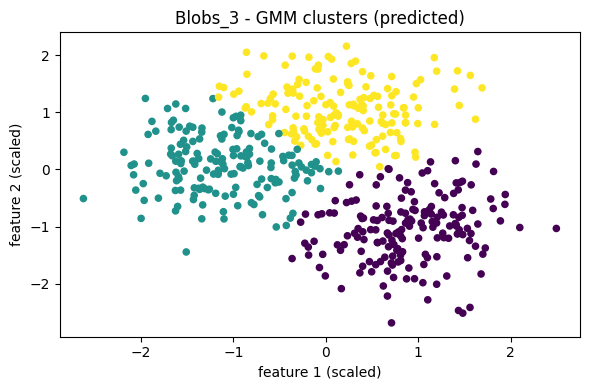

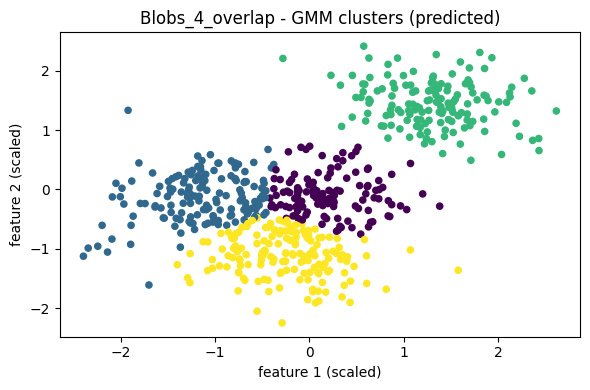

In [ ]:
import numpy as np
import pandas as pd
from sklearn import datasets
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.datasets import make_blobs
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import confusion_matrix

def best_label_mapping(y_true, y_pred):
    """
    Map cluster labels (y_pred) to true labels (y_true) using the Hungarian algorithm.
    Returns mapped predictions.
    """
    cm = confusion_matrix(y_true, y_pred)
    # We want to maximize trace after permuting columns: convert to cost by negation
    row_ind, col_ind = linear_sum_assignment(cm.max() - cm)
    mapping = {}
    for r, c in zip(row_ind, col_ind):
        mapping[c] = r  # map predicted label c -> true label r
    # create mapped prediction array
    y_pred_mapped = np.array([mapping.get(lbl, -1) for lbl in y_pred])
    return y_pred_mapped, mapping, cm

def evaluate_gmm_classifier(X, y, n_components=None, test_size=0.3, random_state=42, scale=True, covariance_type='full'):
    """
    Fits GaussianMixture on training set and evaluates on test set.
    Returns accuracy, report and details.
    """
    if n_components is None:
        n_components = len(np.unique(y))
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, stratify=y, random_state=random_state)

    if scale:
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

    gmm = GaussianMixture(n_components=n_components, covariance_type=covariance_type, random_state=random_state)
    gmm.fit(X_train)

    # For GMM as classifier: predict cluster assignments
    y_pred_test = gmm.predict(X_test)
    y_pred_train = gmm.predict(X_train)

    # Map clusters to actual labels for test set
    y_pred_test_mapped, mapping, cm = best_label_mapping(y_test, y_pred_test)

    acc = accuracy_score(y_test, y_pred_test_mapped)
    report = classification_report(y_test, y_pred_test_mapped, zero_division=0)
    return {
        'accuracy': acc,
        'report': report,
        'mapping': mapping,
        'confusion_matrix': cm,
        'gmm_model': gmm,
        'y_test': y_test,
        'y_pred_test': y_pred_test,
        'y_pred_test_mapped': y_pred_test_mapped
    }

def run_on_datasets(datasets_list):
    results = {}
    for name, (X, y) in datasets_list.items():
        print(f"\n=== Dataset: {name} | samples: {X.shape[0]} features: {X.shape[1]} classes: {len(np.unique(y))} ===")
        res = evaluate_gmm_classifier(X, y, n_components=len(np.unique(y)), test_size=0.3, random_state=42, scale=True)
        print(f"Accuracy: {res['accuracy']:.4f}")
        print("Mapping (pred_cluster -> true_label):", res['mapping'])
        print("Confusion matrix (rows=true labels, cols=pred clusters):\n", res['confusion_matrix'])
        print("Classification report:\n", res['report'])
        results[name] = res
    return results

# Prepare datasets
datasets_list = {}

# 1) Iris
iris = datasets.load_iris()
datasets_list['Iris'] = (iris.data, iris.target)

# 2) Wine
wine = datasets.load_wine()
datasets_list['Wine'] = (wine.data, wine.target)

# 3) Synthetic blobs (3 clusters)
Xb, yb = make_blobs(n_samples=500, centers=3, n_features=2, cluster_std=1.0, random_state=0)
datasets_list['Blobs_3'] = (Xb, yb)

# 4) Synthetic blobs (4 clusters, overlapping)
Xb4, yb4 = make_blobs(n_samples=600, centers=4, n_features=2, cluster_std=2.0, random_state=1)
datasets_list['Blobs_4_overlap'] = (Xb4, yb4)

# Run experiments
results = run_on_datasets(datasets_list)

# If you want to visualize results for synthetic data (optional)
try:
    import matplotlib.pyplot as plt
    for name in ['Blobs_3', 'Blobs_4_overlap']:
        X, y = datasets_list[name]
        res = results[name]
        gmm = res['gmm_model']
        # scale for plotting
        from sklearn.preprocessing import StandardScaler
        scaler = StandardScaler().fit(X)
        Xs = scaler.transform(X)
        y_pred = gmm.predict(Xs)
        plt.figure(figsize=(6,4))
        plt.scatter(Xs[:,0], Xs[:,1], c=y_pred, s=20)
        plt.title(f"{name} - GMM clusters (predicted)")
        plt.xlabel("feature 1 (scaled)")
        plt.ylabel("feature 2 (scaled)")
        plt.tight_layout()
    plt.show()
except Exception as e:
    print("Plotting skipped or failed:", e)
